In [1]:
from PIL import Image
import sys,os
sys.path.append(os.path.abspath(".."))
from torchvision import transforms
from src.setting import model_choices, beta_schedule_choices,images_resolution
from src.trainer import load_pretrained_model
from src.utils.helpers import parse_yml
from easydict import EasyDict
from diffusers import DDIMPipeline, DDIMScheduler


img_path = "clean/1.png"
img = Image.open(img_path).convert("RGB")
method = 'rivaGan'
device = 'cuda:0'

transform = transforms.Compose([
    transforms.Resize((images_resolution[method], images_resolution[method])),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

img_tensor = transform(img)

/home/dongziping/.conda/envs/wmcopier/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# model and pipeline

Tconfig = EasyDict(parse_yml('../configs/config.yaml'))
model = model_choices['unet'](images_resolution[method])

model.eval()
model = model.to(device)
load_pretrained_model(model, accelerator=None, pretrained_ckp='../checkpoints/rivaGan5k.pt')


if not hasattr(Tconfig, 'beta_schedule'):
    Tconfig.beta_schedule = 'linear'
noise_scheduler = DDIMScheduler(num_train_timesteps=1000, trained_betas = beta_schedule_choices[Tconfig.beta_schedule]())
pipeline = DDIMPipeline(unet=model, scheduler=noise_scheduler)

/home/dongziping/.conda/envs/wmcopier/lib/python3.10/site-packages/diffusers/schedulers/scheduling_ddim.py:204: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.betas = torch.tensor(trained_betas, dtype=torch.float32)


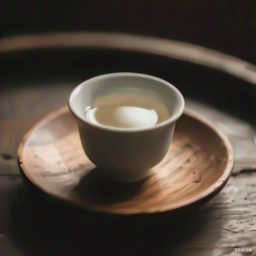

In [8]:
from src.utils.metrics import psnr_ssim
from src.inversion import pred_latents,sample

# forgery
x_0 = img_tensor.to(device).unsqueeze(0)
intermediate_latents = pred_latents(pipeline, x_0, num_inference_steps=100, end_step=40, device=device)

rec_images,_ = sample(x_0, pipeline, start_step=60, start_latents=intermediate_latents,
                        num_inference_steps=100, device=device, refine=True, L=100, eta=0.0001, beta=100)
        
rec_images_norm = rec_images * 0.5 + 0.5

if method in ['dwtdct','rivaGan']:
    rec_images_norm = rec_images_norm.detach().cpu()

forged_pil = transforms.ToPILImage()(rec_images_norm.squeeze())
forged_pil.save("forged_image.png".format(method))
forged_pil

In [7]:
# device for dwtdct and rivaGan is cpu
import sys
from pathlib import Path
cwd = Path(os.getcwd())     
sys.path.append(cwd.parent / 'WMSuite')  
from WMSuite.wm.core.decode import *
from src.setting import target_message_dict
target_message = target_message_dict['rivaGan']
target_message_tensor = torch.Tensor(str2msg(target_message)).to('cpu')
_, decoder = load_models('rivaGan', 'cpu')

# evaluation
tolerant_bits = cal_tolerant(len(target_message),beta=0.000001)
bitwise_accuracy_avg,is_fp,extracted_message = decode_single_image(rec_images_norm.squeeze(), target_message_tensor, 'cpu', decoder, tolerant_bits)
print("Bitwise Accuracy: {:.2f}, Contain Watermark: {}".format(bitwise_accuracy_avg, is_fp))

psnr, ssim = psnr_ssim(x_0, rec_images)
print("PSNR: {:.4f}, SSIM: {:.4f}".format(psnr, ssim))

Bitwise Accuracy: 1.00, Contain Watermark: True
PSNR: 35.6352, SSIM: 0.9338
